# XGBoost Launch Failure Modeling (Time-Aware)
This notebook trains and evaluates XGBoost models using chronological splits and TimeSeriesSplit.

In [55]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, balanced_accuracy_score
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
DATA_DIR = Path("data_final")
NOAA_DIR = DATA_DIR / "NOAA_data"
DERIVED_DIR = DATA_DIR / "derived"
OUTPUT_DIR = Path("xgboost_out")
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)
DATASETPATH = DERIVED_DIR / "launch_modeling_base_with_weather.csv"
DATA_PATH = Path(DATASETPATH)

In [ ]:
df = pd.read_csv(DATA_PATH, low_memory=False)
#df.head()
#print(df.columns.tolist())
#print(df["data_split"].value_counts())
'''
data_split
train         4317
test           926
validation     925

                                  min                        max
data_split                                                      
test        2012-11-10 21:05:00+00:00  2021-12-30 03:30:00+00:00
train       1957-10-04 19:28:00+00:00  1999-07-08 08:45:00+00:00
validation  1999-07-10 08:45:00+00:00  2012-11-02 21:03:00+00:00

Shape: (6168, 89)
launch_failure_binary
0    5626
1     542

'''
#print(df.groupby("data_split")["launch_time_utc"].agg(["min", "max"]))
df["launch_time_utc"] = pd.to_datetime(df["launch_time_utc"], errors="coerce")
df = df.sort_values("launch_time_utc").reset_index(drop=True)
#df.head()

df["launch_failure_binary"] = df["is_failure_or_partial"].astype(int)
print(df.groupby("data_split")["launch_failure_binary"].mean())

print("Shape:", df.shape)
print(df["launch_failure_binary"].value_counts())
'''
data_split
test          0.059395
train         0.099606
validation    0.061622
'''


data_split
test          0.059395
train         0.099606
validation    0.061622
Name: launch_failure_binary, dtype: float64
Shape: (6168, 89)
launch_failure_binary
0    5626
1     542
Name: count, dtype: int64


# Data Split Validation Summary

To verify the integrity of the modeling dataset, three key checks were performed on the predefined data_split column.

- Split Distribution Check

``
Result:

Train: 4,317 observations (~70%)
Validation: 925 observations (~15%)
Test: 926 observations (~15%)

Interpretation:
The dataset is well-balanced across splits, with a sufficiently large training set for model learning and adequately sized validation and test sets for reliable evaluation.

- Chronological Consistency Check

`df.groupby("data_split")["launch_time_utc"].agg(["min", "max"])`

Result:

Train: 1957 → 1999
Validation: 1999 → 2012
Test: 2012 → 2021

Interpretation:
The splits are strictly chronological with no overlap, ensuring:

No data leakage from future to past
Realistic forward-looking evaluation
Alignment with time-aware modeling best practices

- Failure Rate Distribution Check

`df.groupby("data_split")["launch_failure_binary"].mean()`

Result:

Train: ~9.96%
Validation: ~6.16%
Test: ~5.94%

Interpretation:
Failure rates decrease over time, reflecting improvements in launch reliability. This confirms that:

The dataset captures real-world temporal trends
The model is trained on a higher-risk historical regime and evaluated on a lower-risk modern regime
The evaluation setup is both realistic and appropriately challenging

- Overall Conclusion

These checks confirm that the dataset split is:


    - Chronologically correct
    - Free from data leakage
    - Representative of real-world temporal dynamics


This provides a strong and credible foundation for comparing model performance across different feature sets and modeling approaches.


In [ ]:
base_numeric = [
    "family_success_rate_pct",
    "mission_mass",
    "config_liftoff_thrust",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "payload_count"
]

base_categorical = [
    "facility_group",
    "rocket_family"
]

weather_numeric = base_numeric + [
    "HourlyWindSpeed",
    "HourlyVisibility",
    "HourlyRelativeHumidity",
    #"dewpoint_depression",
    "weather_time_diff_minutes"
]

weather_categorical = base_categorical + [
    #"weather_match_quality_bin",
    "present_weather_rain_flag",
    "present_weather_fog_flag",
    "cloud_cover_broken_or_overcast_flag"
]

In [ ]:
missing = [c for c in weather_numeric + weather_categorical if c not in df.columns]
print(missing)
#adding missing features for weather
'''df["dewpoint_depression"] = (
    df["HourlyDryBulbTemperature"] - df["HourlyDewPointTemperature"]
)
df["weather_match_quality_bin"] = pd.cut(
    df["weather_time_diff_minutes"],
    bins=[0, 15, 30, 60, 120],
    labels=["0-15", "15-30", "30-60", "60-120"]
)
missing = [c for c in weather_numeric + weather_categorical if c not in df.columns]
print(missing)'''

['dewpoint_depression', 'weather_match_quality_bin']
[]


In [24]:
def build_preprocessor(num_cols, cat_cols):
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ])

In [25]:
def build_model(scale_pos_weight):
    return XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    )

In [26]:
def evaluate(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
    }

In [44]:
def run_xgb_experiment(train_df, val_df, test_df, num_cols, cat_cols, name):
    
    features = num_cols + cat_cols

    X_train = train_df[features]
    y_train = train_df["launch_failure_binary"]

    X_val = val_df[features]
    y_val = val_df["launch_failure_binary"]

    X_test = test_df[features]
    y_test = test_df["launch_failure_binary"]

    # handle imbalance
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    pipe = Pipeline([
        ("prep", build_preprocessor(num_cols, cat_cols)),
        ("model", build_model(scale_pos_weight))
    ])

    # train
    pipe.fit(X_train, y_train)

    # validation predictions
    val_proba = pipe.predict_proba(X_val)[:, 1]

    # --- threshold tuning ---
    thresholds = np.linspace(0.1, 0.9, 50)
    best_thresh = 0.5
    best_score = 0

    for t in thresholds:
        pred = (val_proba >= t).astype(int)
        score = balanced_accuracy_score(y_val, pred)

        if score > best_score:
            best_score = score
            best_thresh = t

    # test predictions
    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_thresh).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_test, test_proba),
        "pr_auc": average_precision_score(y_test, test_proba),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "threshold": best_thresh
    }

    print(f"\n=== {name} ===")
    print(metrics)

    return metrics, pipe

In [ ]:
#use the column from data pipeline csv for splitting
train_df = df[df["data_split"] == "train"].copy()
val_df   = df[df["data_split"] == "validation"].copy()
test_df  = df[df["data_split"] == "test"].copy()

In [46]:
# Run full dataset experiments

base_results, base_model  = run_xgb_experiment(
    train_df, val_df, test_df,
    base_numeric,
    base_categorical,
    "XGBoost Base (No Weather)"
)

weather_results, weather_model = run_xgb_experiment(
    train_df, val_df, test_df,
    weather_numeric,
    weather_categorical,
    "XGBoost With Weather"
)


=== XGBoost Base (No Weather) ===
{'roc_auc': 0.7613401523849286, 'pr_auc': 0.3535709967021598, 'balanced_accuracy': 0.7018578436488885, 'precision': 0.11083743842364532, 'recall': 0.8181818181818182, 'f1': 0.19522776572668113, 'threshold': np.float64(0.3122448979591837)}

=== XGBoost With Weather ===
{'roc_auc': 0.7628640016699717, 'pr_auc': 0.33375273121147336, 'balanced_accuracy': 0.6995616323974534, 'precision': 0.10975609756097561, 'recall': 0.8181818181818182, 'f1': 0.1935483870967742, 'threshold': np.float64(0.1326530612244898)}


In [ ]:
# Weather quality subset
weather_subset = df[
    (df["weather_matched"] == True) &
    (df["weather_time_diff_minutes"] <= 30)
].copy()

print("Subset size:", weather_subset.shape)


# re-split subset using same labels
sub_train = weather_subset[weather_subset["data_split"] == "train"].copy()
sub_val   = weather_subset[weather_subset["data_split"] == "validation"].copy()
sub_test  = weather_subset[weather_subset["data_split"] == "test"].copy()


# Run subset experiments
subset_base, subset_base_model = run_xgb_experiment(
    sub_train, sub_val, sub_test,
    base_numeric,
    base_categorical,
    "Subset Base"
)

subset_weather, subset_weather_model = run_xgb_experiment(
    sub_train, sub_val, sub_test,
    weather_numeric,
    weather_categorical,
    "Subset Weather"
)

Subset size: (2334, 91)

=== Subset Base ===
{'roc_auc': 0.8508333333333333, 'pr_auc': 0.4110949618773801, 'balanced_accuracy': 0.7945588235294118, 'precision': 0.14556962025316456, 'recall': 0.92, 'f1': 0.25136612021857924, 'threshold': np.float64(0.2142857142857143)}

=== Subset Weather ===
{'roc_auc': 0.8008823529411764, 'pr_auc': 0.4420454900457451, 'balanced_accuracy': 0.7223529411764706, 'precision': 0.1504424778761062, 'recall': 0.68, 'f1': 0.2463768115942029, 'threshold': np.float64(0.1)}


In [38]:
comparison = pd.DataFrame({
    "Base": base_results,
    "Weather": weather_results
})

subset_comparison = pd.DataFrame({
    "Subset Base": subset_base,
    "Subset Weather": subset_weather
})

comparison, subset_comparison

(                       Base   Weather
 roc_auc            0.761340  0.762864
 pr_auc             0.353571  0.333753
 balanced_accuracy  0.701858  0.699562
 precision          0.110837  0.109756
 recall             0.818182  0.818182
 f1                 0.195228  0.193548
 threshold          0.312245  0.132653,
                    Subset Base  Subset Weather
 roc_auc               0.850833        0.800882
 pr_auc                0.411095        0.442045
 balanced_accuracy     0.794559        0.722353
 precision             0.145570        0.150442
 recall                0.920000        0.680000
 f1                    0.251366        0.246377
 threshold             0.214286        0.100000)

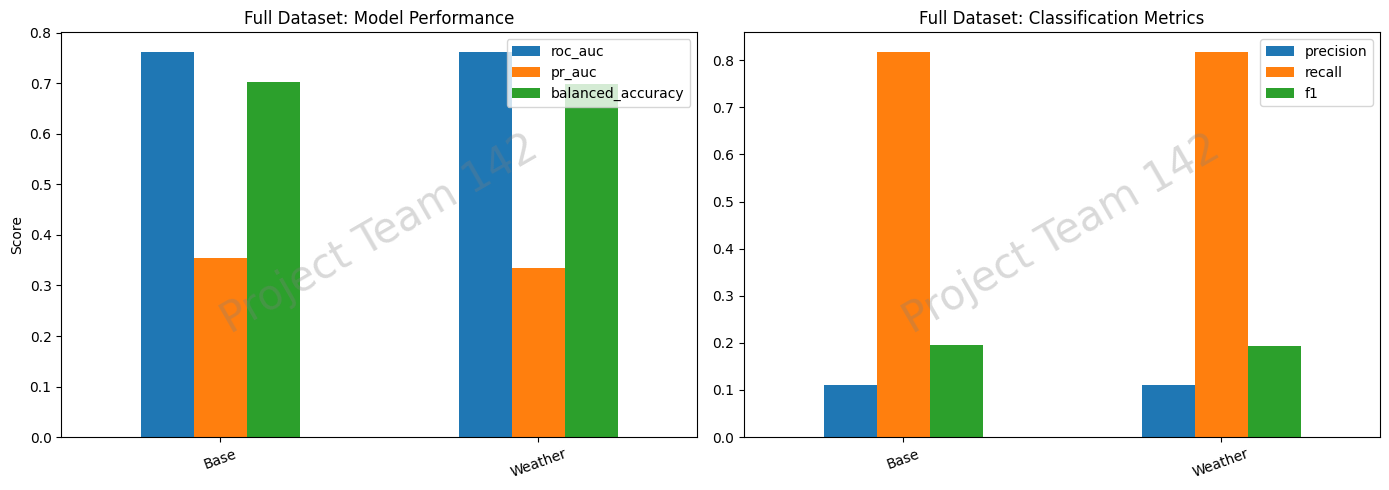

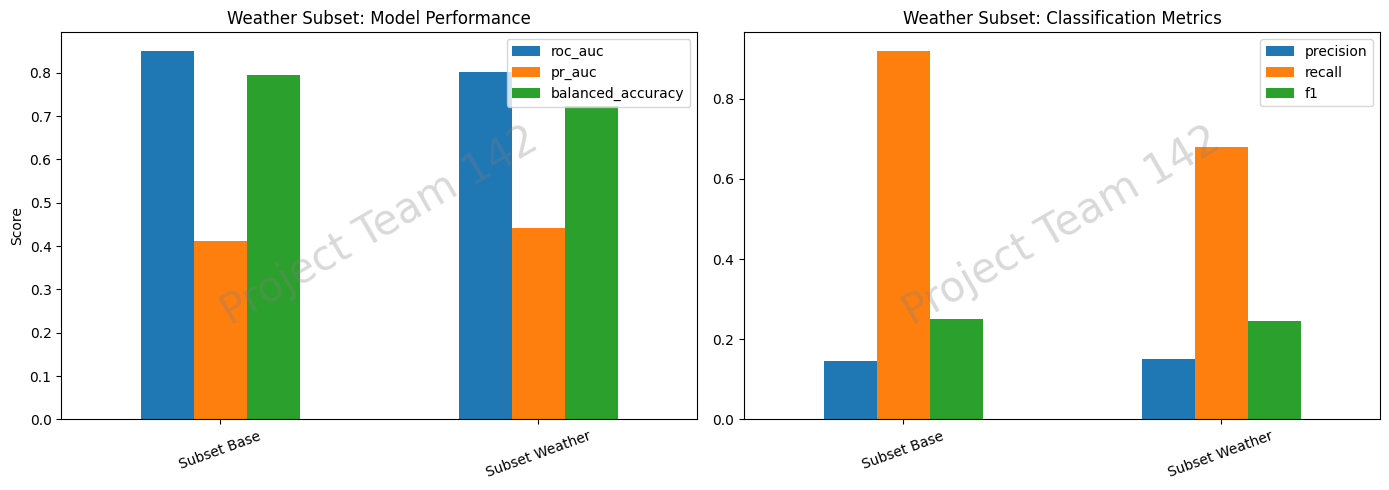

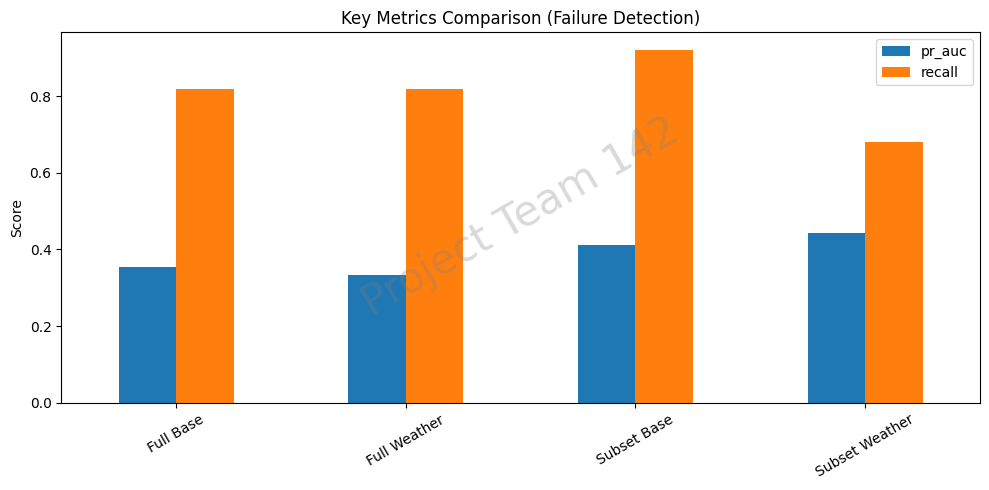

In [69]:
# -------------------------
# Combine results
# -------------------------

full_df = pd.DataFrame({
    "Base": base_results,
    "Weather": weather_results
})

subset_df = pd.DataFrame({
    "Subset Base": subset_base,
    "Subset Weather": subset_weather
})

# -------------------------
# Plot 1: Full dataset comparison
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,5))

full_df.T[["roc_auc", "pr_auc", "balanced_accuracy"]].plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Full Dataset: Model Performance")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)
axes[0].text(0.5, 0.5, 'Project Team 142', fontsize=30, color='gray', alpha=0.3, ha='center', va='center', rotation=30, transform=axes[0].transAxes)

full_df.T[["precision", "recall", "f1"]].plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Full Dataset: Classification Metrics")
axes[1].tick_params(axis="x", rotation=20)
axes[1].text(0.5, 0.5, 'Project Team 142', fontsize=30, color='gray', alpha=0.3, ha='center', va='center', rotation=30, transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_fullds.png")
plt.show()


# -------------------------
# Plot 2: Subset comparison
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(14,5))

subset_df.T[["roc_auc", "pr_auc", "balanced_accuracy"]].plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Weather Subset: Model Performance")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=20)
axes[0].text(0.5, 0.5, 'Project Team 142', fontsize=30, color='gray', alpha=0.3, ha='center', va='center', rotation=30, transform=axes[0].transAxes)

subset_df.T[["precision", "recall", "f1"]].plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Weather Subset: Classification Metrics")
axes[1].tick_params(axis="x", rotation=20)
axes[1].text(0.5, 0.5, 'Project Team 142', fontsize=30, color='gray', alpha=0.3, ha='center', va='center', rotation=30, transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_weathersubds.png")
plt.show()


# -------------------------
# Plot 3: Focus on PR AUC + Recall (MOST IMPORTANT)
# -------------------------

important_metrics = pd.DataFrame({
    "Full Base": base_results,
    "Full Weather": weather_results,
    "Subset Base": subset_base,
    "Subset Weather": subset_weather
})

important_metrics.T[["pr_auc", "recall"]].plot(kind="bar", figsize=(10,5))
plt.title("Key Metrics Comparison (Failure Detection)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.text(0.5,0.5,"Project Team 142",fontsize=30,color="gray",alpha=0.3,ha="center",va="center",rotation=30,transform=plt.gca().transAxes)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_keymetrics.png")
plt.show()


In [68]:
# Get test predictions probabilities as risk scores (use best model, e.g. base_model or weather_model)

test_df = test_df.copy()

test_df["risk_score"] = base_model.predict_proba(test_df[base_numeric + base_categorical])[:, 1]

test_df[["risk_score", "launch_failure_binary"]].head()

,risk_score,launch_failure_binary
5242,0.746771,0
5243,0.219727,0
5244,0.013360,0
5245,0.656085,0
5246,0.466589,0


## Risk Score Analysis and Visualization

To better understand how well the model ranks launch risk, we analyzed the **predicted probabilities from the XGBoost base model** as a continuous **risk score**. Instead of focusing only on binary classification (success/failure), this approach evaluates how effectively the model orders launches from low to high risk.

---

### 1. Risk Score Distribution (Success vs Failure)

**What we did:**
- Used the predicted probability of failure from the model as a **risk score**.
- Split the test dataset into:
  - Successful launches (`launch_failure_binary = 0`)
  - Failed launches (`launch_failure_binary = 1`)
- Plotted separate histograms for each group.

**Purpose:**
- To visually compare how risk scores are distributed across successes and failures.

**Interpretation:**
- Successful launches are mostly concentrated at **lower risk scores**.
- Failures are more spread out and tend to appear more frequently at **higher risk scores**.
- Some overlap exists, which is expected due to the probabilistic nature of the model.


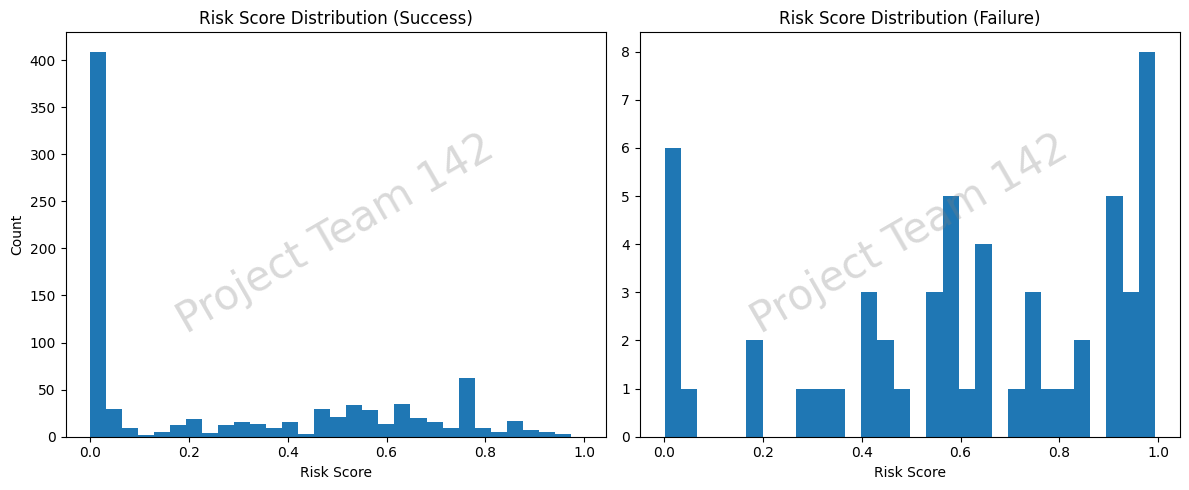

In [67]:

test_df.groupby("launch_failure_binary")["risk_score"].describe()


fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True)

# Success distribution
axes[0].hist(
    test_df[test_df["launch_failure_binary"] == 0]["risk_score"],
    bins=30
)
axes[0].set_title("Risk Score Distribution (Success)")
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Count")
axes[0].text(0.5, 0.5, 'Project Team 142', fontsize=30, color='gray', alpha=0.3, ha='center', va='center', rotation=30, transform=axes[0].transAxes)

# Failure distribution
axes[1].hist(
    test_df[test_df["launch_failure_binary"] == 1]["risk_score"],
    bins=30
)
axes[1].set_title("Risk Score Distribution (Failure)")
axes[1].set_xlabel("Risk Score")
axes[1].text(0.5, 0.5, 'Project Team 142', fontsize=30, color='gray', alpha=0.3, ha='center', va='center', rotation=30, transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "risk_score_dist_for_success_failure.png")
plt.show()


### 2. Failure Rate vs Risk Score (Binned)

**What we did:**
- Divided the risk scores into **equal-width bins** using `pd.cut()` (e.g., 10 bins across 0–1 range).
- For each bin:
  - Calculated the **average failure rate** (`mean of launch_failure_binary`).

**Purpose:**
- To understand how failure probability changes as risk score increases.

**Interpretation:**
- Failure rates generally increase as risk score increases.
- The trend may not be perfectly smooth due to:
  - Imbalanced data (few failures)
  - Fewer samples in higher-risk bins
- This confirms that higher predicted risk corresponds to higher actual failure likelihood.

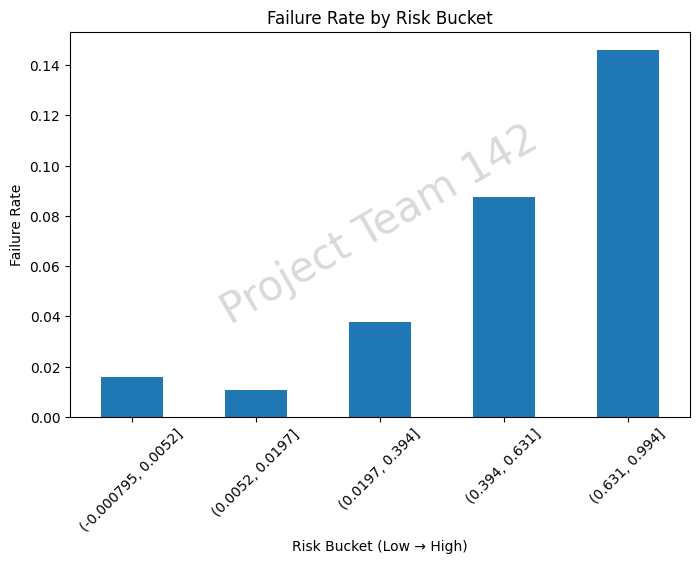

In [ ]:
test_df["risk_bucket"] = pd.qcut(test_df["risk_score"], q=5)

bucket_stats = test_df.groupby("risk_bucket")["launch_failure_binary"].mean()

bucket_stats

bucket_stats.plot(kind="bar", figsize=(8,5))
plt.title("Failure Rate by Risk Bucket")
plt.ylabel("Failure Rate")
plt.xlabel("Risk Bucket (Low → High)")
plt.xticks(rotation=45)
plt.text(0.5,0.5,"Project Team 142",fontsize=30,color="gray",alpha=0.3,ha="center",va="center",rotation=30,transform=plt.gca().transAxes)
plt.savefig(PLOTS_DIR / "failrate_by_bucket.png")
plt.show()

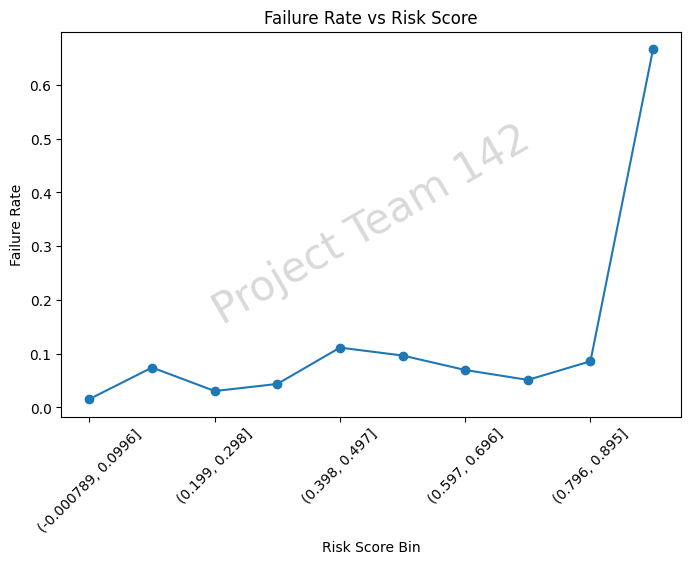

In [66]:
#Failure rate vs risk score (smoothed or binned) - Bin based
# Create bins
test_df["risk_bin"] = pd.cut(test_df["risk_score"], bins=10)

# Compute failure rate per bin
bin_stats = test_df.groupby("risk_bin")["launch_failure_binary"].mean()

# Plot
plt.figure(figsize=(8,5))
bin_stats.plot(marker='o')

plt.title("Failure Rate vs Risk Score")
plt.xlabel("Risk Score Bin")
plt.ylabel("Failure Rate")
plt.xticks(rotation=45)
plt.text(0.5,0.5,"Project Team 142",fontsize=30,color="gray",alpha=0.3,ha="center",va="center",rotation=30,transform=plt.gca().transAxes)
plt.savefig(PLOTS_DIR / "failrate_bins.png")
plt.show()


### 3. Failure Rate Above Risk Threshold

**What we did:**
- Created a range of thresholds between 0 and 1.
- For each threshold:
  - Selected launches with `risk_score ≥ threshold`
  - Calculated the failure rate within that subset

**Purpose:**
- To simulate a decision rule:
  > “If we focus only on launches above a certain risk score, how risky are they?”

**Interpretation:**
- As the threshold increases:
  - The subset becomes smaller
  - The **failure rate increases**
- At higher thresholds (e.g., > 0.7), failure rates rise sharply
- This shows that the model effectively **concentrates failures in high-risk predictions**


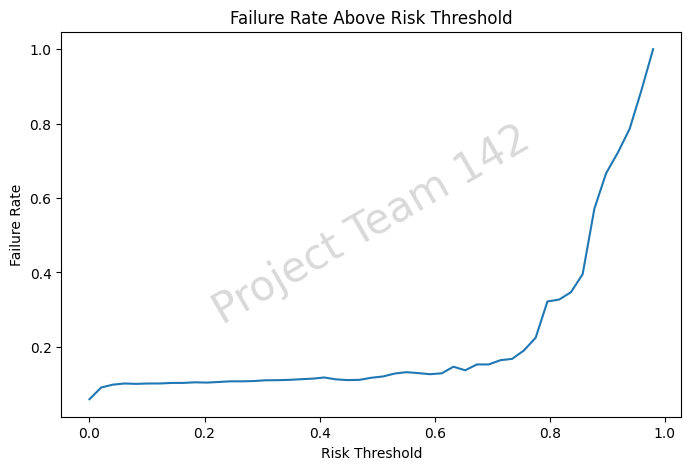

In [65]:
#Failure rate vs risk score (smoothed or binned) - cumulative threshold curve

thresholds = np.linspace(0, 1, 50)
failure_rates = []

for t in thresholds:
    subset = test_df[test_df["risk_score"] >= t]
    if len(subset) > 0:
        failure_rates.append(subset["launch_failure_binary"].mean())
    else:
        failure_rates.append(np.nan)

plt.figure(figsize=(8,5))
plt.plot(thresholds, failure_rates)

plt.title("Failure Rate Above Risk Threshold")
plt.xlabel("Risk Threshold")
plt.ylabel("Failure Rate")
plt.text(0.5,0.5,"Project Team 142",fontsize=30,color="gray",alpha=0.3,ha="center",va="center",rotation=30,transform=plt.gca().transAxes)
plt.savefig(PLOTS_DIR / "failrate_smooth.png")
plt.show()


### 4. Top 10% Risk Analysis

**What we did:**
- Sorted launches in the test dataset by their predicted **risk score** (highest to lowest).
- Selected the **top 10% highest-risk launches**.
- Calculated the failure rate within this subset.
- Compared it to the **overall failure rate** in the dataset.

**Results:**
- Failure rate in top 10%: **21.74%**
- Failure rate in top 5%: **36.96%**
- Failure rate in top 20%: **14.59%**
- Overall failure rate: **5.94%**

**Purpose:**
- To evaluate how well the model concentrates failures in the highest-risk predictions.

**Interpretation:**
- The top 10% highest-risk launches have a failure rate that is **~3.7× higher** than the overall baseline.
- This indicates that the model is effectively identifying a subset of launches with **significantly elevated risk**.
- The top 10% highest-risk launches exhibit a failure rate of 21.7%, compared to a baseline of 5.9%, representing a ~3.7× increase. More extreme filtering (top 5%) yields even higher concentration (~36.9%), while broader selection (top 20%) increases coverage at the cost of lower precision.

Even though the model is not a perfect classifier, it is highly useful for:
- **Prioritizing high-risk launches**
- **Flagging launches for further review**
- **Supporting decision-making based on relative risk**

In [79]:
top_20 = test_df.sort_values("risk_score", ascending=False).head(int(0.2 * len(test_df)))
top_05 = test_df.sort_values("risk_score", ascending=False).head(int(0.05 * len(test_df)))
top_10 = test_df.sort_values("risk_score", ascending=False).head(int(0.1 * len(test_df)))

print(f"Overall (Baseline) failure rate: {test_df['launch_failure_binary'].mean():.2%}")
print(f"Failure rate in top 10%: {top_10['launch_failure_binary'].mean():.2%}")
print(f"Failure rate in top 5%: {top_05['launch_failure_binary'].mean():.2%}")
print(f"Failure rate in top 20%: {top_20['launch_failure_binary'].mean():.2%}")


Overall (Baseline) failure rate: 5.94%
Failure rate in top 10%: 21.74%
Failure rate in top 5%: 36.96%
Failure rate in top 20%: 14.59%


## Summary Insight

- The model does not create a perfect separation between success and failure.
- However, it provides a meaningful **risk ranking**:
  - Low scores → mostly safe launches  
  - High scores → significantly higher failure probability  

This makes the model useful as a **risk prioritization tool**, even if classification accuracy is limited.